In [5]:
import pandas as pd

In [6]:
df = pd.read_feather('../dataset/top_12500.feather')
df.index = pd.to_datetime(df.index)
#df['date'] = pd.to_datetime(df['date'])

# Categorize & cluster products with `ete_ts`

For every product (`item_id`) we extract the 14 `ete_ts.all_metrics` features from its
`value` series (daily, sf=1), then cluster products into data-driven categories with KMeans.

Features (in order returned by `all_metrics`): trend_strength, trend_changes, lr_slope,
lr_r2, forecastability, fluctuation, ac_relevance, seasonal_strength, window_fluctuation,
st_variation, diff_series, complexity, rec_concentration, centroid.

> Note: `all_metrics` uses the library default `period=12` inside trend/seasonal strength.
> For daily retail data a weekly (`7`) period is often more meaningful; tune later if needed.

In [7]:
# --- 1. Build the per-product feature matrix (ete_ts fingerprints) ---
import numpy as np
import ete_ts

SF = 1  # daily sampling -> 1 sample/day
FEATURE_NAMES = ["trend_strength", "trend_changes", "lr_slope", "lr_r2",
    "forecastability", "fluctuation", "ac_relevance", "seasonal_strength",
    "window_fluctuation", "st_variation", "diff_series", "complexity",
    "rec_concentration", "centroid"]

records = []
for item, g in df.sort_index().groupby("item_id"):
    s = g["value"].astype(float).to_numpy()
    if len(s) < 30 or np.allclose(s, s[0]):   # skip too-short / constant series
        continue
    feats = ete_ts.all_metrics(s, SF)
    rec = {"item_id": item, **dict(zip(FEATURE_NAMES, feats))}
    rec["cat_label"] = g["cat_label"].mode().iat[0]   # existing label, for comparison
    records.append(rec)

feat_df = pd.DataFrame(records).set_index("item_id")
print("products:", feat_df.shape[0], "| features:", len(FEATURE_NAMES))
feat_df.head()

products: 61 | features: 14


,trend_strength,trend_changes,lr_slope,lr_r2,forecastability,fluctuation,ac_relevance,seasonal_strength,window_fluctuation,st_variation,diff_series,complexity,rec_concentration,centroid,cat_label
item_id,,,,,,,,,,,,,,,
278,0.488744,112,0.008926,0.031147,0.155963,0.946053,1.849465,0.328558,0.872340,-0.821011,0.162730,27.813961,-0.533027,428.133101,sour cream
457,0.310133,117,-0.015193,0.133217,0.154048,0.930263,0.894436,0.303720,0.680851,-0.665499,0.216147,32.762516,-0.518155,305.444903,refrigerated drnks
1325,0.190370,109,-0.005852,0.024481,0.150090,0.959211,0.746824,0.284856,0.170213,-0.275550,0.234328,35.884078,-0.190106,354.638627,refrigerated drnks
6032,0.449976,118,0.007201,0.012045,0.163335,0.932895,1.726573,0.313254,0.361702,-1.012282,0.154327,25.838327,0.101442,426.108958,dips refrigerated
13544,0.368967,146,0.002565,0.000144,0.180350,0.948684,2.139969,0.494527,0.148936,0.045775,0.087493,23.881008,-0.787867,378.096823,bottled water


In [8]:
# --- 2. Clean & standardize ---
from sklearn.preprocessing import StandardScaler

X_df = feat_df[FEATURE_NAMES].replace([np.inf, -np.inf], np.nan)
nan_cols = X_df.isna().sum()
print("NaNs per feature:", nan_cols[nan_cols > 0].to_dict() or "none")
X_df = X_df.fillna(X_df.median())

scaler = StandardScaler()
Xs = scaler.fit_transform(X_df.values)

NaNs per feature: none


silhouette by k: {2: 0.255, 3: 0.149, 4: 0.164, 5: 0.186, 6: 0.187, 7: 0.163, 8: 0.17, 9: 0.172, 10: 0.174}
best k (silhouette): 2


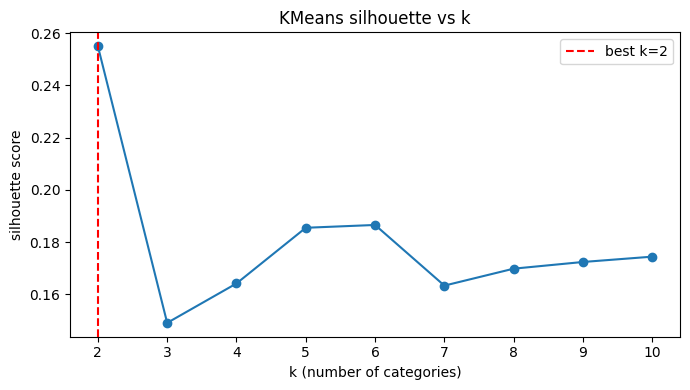

In [9]:
# --- 3. Choose number of categories (k) by silhouette ---
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sil = {}
for k in range(2, 11):
    labels = KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(Xs)
    sil[k] = silhouette_score(Xs, labels)
best_k = max(sil, key=sil.get)
print("silhouette by k:", {k: round(v, 3) for k, v in sil.items()})
print("best k (silhouette):", best_k)

plt.figure(figsize=(7, 4))
plt.plot(list(sil), list(sil.values()), "o-")
plt.axvline(best_k, ls="--", c="r", label=f"best k={best_k}")
plt.xlabel("k (number of categories)"); plt.ylabel("silhouette score")
plt.title("KMeans silhouette vs k"); plt.legend(); plt.tight_layout(); plt.show()

In [10]:
# --- 4. Fit final clustering (override K here if you want a fixed #categories) ---
K = best_k          # e.g. set K = 5 for a finer categorization
km = KMeans(n_clusters=K, n_init=10, random_state=42).fit(Xs)
feat_df["cluster"] = km.labels_
print(f"K = {K}")
print("cluster sizes:", feat_df["cluster"].value_counts().sort_index())

K = 2
cluster sizes: cluster
0    43
1    18
Name: count, dtype: int64


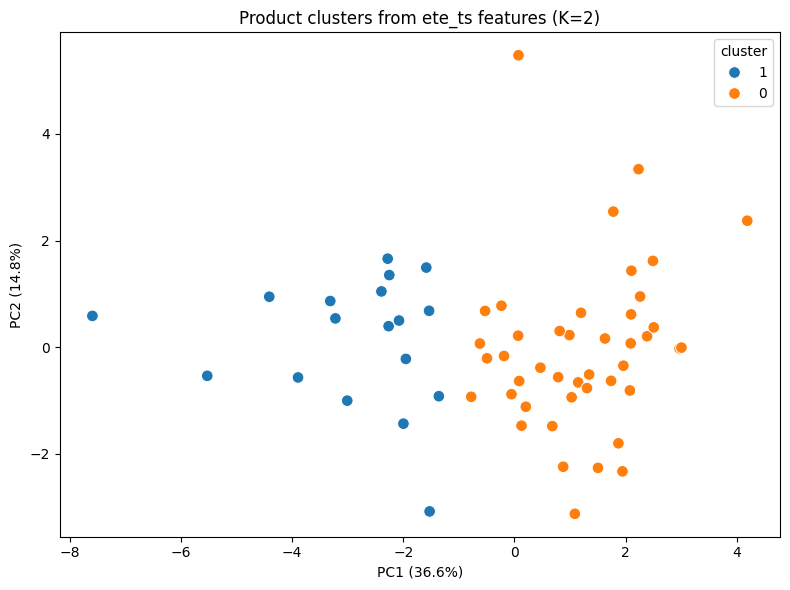

In [11]:
# --- 5. PCA projection of the product clusters ---
import seaborn as sns
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
emb = pca.fit_transform(Xs)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=emb[:, 0], y=emb[:, 1],
                hue=feat_df["cluster"].astype(str), palette="tab10", s=70)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title(f"Product clusters from ete_ts features (K={K})")
plt.legend(title="cluster"); plt.tight_layout(); plt.show()

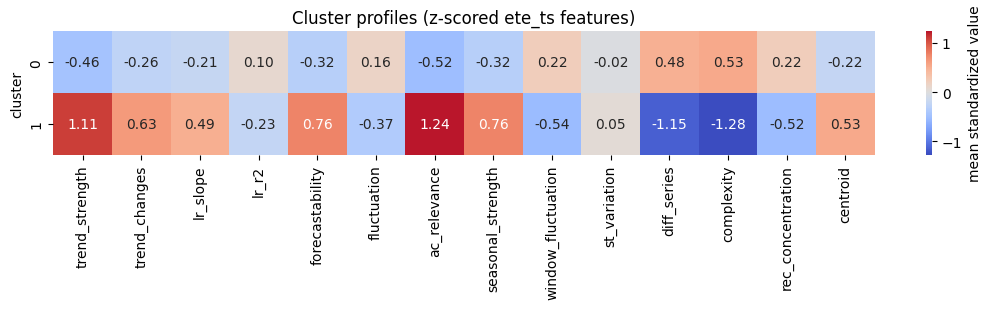

,trend_strength,trend_changes,lr_slope,lr_r2,forecastability,fluctuation,ac_relevance,seasonal_strength,window_fluctuation,st_variation,diff_series,complexity,rec_concentration,centroid
cluster,,,,,,,,,,,,,,
0,-0.462820,-0.264761,-0.207175,0.095218,-0.318456,0.156259,-0.517963,-0.319726,0.223979,-0.020601,0.482209,0.534685,0.219396,-0.222525
1,1.105624,0.632486,0.494919,-0.227465,0.760755,-0.373287,1.237355,0.763789,-0.535061,0.049213,-1.151943,-1.277302,-0.524113,0.531587


In [12]:
# --- 6. Interpret each cluster: mean z-scored feature profile ---
profile = (pd.DataFrame(Xs, columns=FEATURE_NAMES, index=feat_df.index)
           .assign(cluster=feat_df["cluster"]).groupby("cluster").mean())

plt.figure(figsize=(11, 0.6 * K + 2))
sns.heatmap(profile, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            cbar_kws={"label": "mean standardized value"})
plt.title("Cluster profiles (z-scored ete_ts features)")
plt.ylabel("cluster"); plt.tight_layout(); plt.show()
profile

In [13]:
# --- 7. Do data-driven clusters align with the existing cat_label? ---
from IPython.display import display
ct = pd.crosstab(feat_df["cluster"], feat_df["cat_label"])
display(ct)
print("Dominant existing cat_label per cluster:")
print(ct.idxmax(axis=1))

cat_label,bottled water,carbonated sft drnks,cream chs,dairy chs,dairy cream,dips refrigerated,eggs egg substitutes,milknplant based bevs,refrigerated drnks,rte cereal,sour cream,sparkling seltzer mixer,sprd btr mrgrn,yogurt
cluster,,,,,,,,,,,,,,
0,2,5,0,3,1,0,7,12,4,0,0,5,0,4
1,1,6,2,0,1,1,1,0,0,2,1,0,3,0


Dominant existing cat_label per cluster:
cluster
0    milknplant based bevs
1     carbonated sft drnks
dtype: object


In [15]:
# --- 8. Export the per-product categorization ---
out = (feat_df.reset_index()[["item_id", "cat_label", "cluster"] + FEATURE_NAMES]
       .sort_values(["cluster", "item_id"]))
out.to_csv("product_feature_clusters.csv", index=False)
print("saved product_feature_clusters.csv", out.shape)
out

saved product_feature_clusters.csv (61, 17)


,item_id,cat_label,cluster,trend_strength,trend_changes,lr_slope,lr_r2,forecastability,fluctuation,ac_relevance,seasonal_strength,window_fluctuation,st_variation,diff_series,complexity,rec_concentration,centroid
1,457,refrigerated drnks,0,0.310133,117,-0.015193,0.133217,0.154048,0.930263,0.894436,0.303720,0.680851,-0.665499,0.216147,32.762516,-0.518155,305.444903
2,1325,refrigerated drnks,0,0.190370,109,-0.005852,0.024481,0.150090,0.959211,0.746824,0.284856,0.170213,-0.275550,0.234328,35.884078,-0.190106,354.638627
5,16920,yogurt,0,0.196622,123,-0.006301,0.014307,0.153758,0.947368,0.727401,0.267423,0.872340,-0.025334,0.251298,36.333524,-0.426003,348.891134
7,25032,yogurt,0,0.266573,123,-0.000953,0.000219,0.155427,0.950000,0.804356,0.304365,0.851064,-0.319175,0.232191,34.562209,-0.684723,381.755052
10,26076,yogurt,0,0.321297,127,-0.005280,0.009805,0.154050,0.934211,0.852093,0.309219,0.808511,-0.299931,0.222397,33.570643,-0.523479,364.179992
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46,907969,eggs egg substitutes,1,0.367903,144,0.016806,0.007355,0.174957,0.973684,1.379019,0.258586,0.723404,-0.932292,0.177267,28.022420,-0.713096,397.311758
48,908786,carbonated sft drnks,1,0.462106,127,-0.001556,0.000424,0.162130,0.947368,1.798211,0.308904,0.297872,-0.522774,0.108208,25.829654,-0.224601,375.146759
54,919137,carbonated sft drnks,1,0.384405,144,-0.014335,0.016871,0.167362,0.971053,1.899195,0.352689,0.234043,0.399870,0.068679,24.965013,-0.515966,350.207869
57,933442,carbonated sft drnks,1,0.465736,138,-0.002151,0.000499,0.160728,0.950000,1.956358,0.379012,0.255319,0.030799,0.131369,26.474153,-0.532917,364.014812
